In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Data/processed/clean_house_data.csv")
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,1875.0,3.0,1.0,167.0,3,8906.666667,625.000000
1,Built-up Area,Ready To Move,1st Phase JP Nagar,5 Bedroom,1500.0,5.0,2.0,85.0,5,5666.666667,300.000000
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2065.0,4.0,1.0,210.0,3,10169.491525,688.333333
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,3 BHK,2059.0,3.0,2.0,225.0,3,10927.634774,686.333333
4,Super built-up Area,Ready To Move,1st Phase JP Nagar,2 BHK,1394.0,2.0,1.0,100.0,2,7173.601148,697.000000


In [2]:
df.shape

(7296, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7296 entries, 0 to 7295
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       7296 non-null   object 
 1   availability    7296 non-null   object 
 2   location        7296 non-null   object 
 3   size            7296 non-null   object 
 4   total_sqft      7296 non-null   float64
 5   bath            7296 non-null   float64
 6   balcony         7296 non-null   float64
 7   price           7296 non-null   float64
 8   bhk             7296 non-null   int64  
 9   price_per_sqft  7296 non-null   float64
 10  sqft_per_bhk    7296 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 627.1+ KB


In [4]:
df.isnull().sum()

area_type         0
availability      0
location          0
size              0
total_sqft        0
bath              0
balcony           0
price             0
bhk               0
price_per_sqft    0
sqft_per_bhk      0
dtype: int64

***

In [5]:
df_model = df.drop(
    ["size", "price_per_sqft", "sqft_per_bhk"],
    axis=1
)

In [6]:
df_model.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Ready To Move,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3
1,Built-up Area,Ready To Move,1st Phase JP Nagar,1500.0,5.0,2.0,85.0,5
2,Super built-up Area,Ready To Move,1st Phase JP Nagar,2065.0,4.0,1.0,210.0,3
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,2059.0,3.0,2.0,225.0,3
4,Super built-up Area,Ready To Move,1st Phase JP Nagar,1394.0,2.0,1.0,100.0,2


In [7]:
df_model.columns

Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price', 'bhk'],
      dtype='object')

In [8]:
df_model["availability"].value_counts().head(20)

availability
Ready To Move    5783
18-Dec            164
18-May            152
18-Apr            147
18-Aug            117
19-Dec            105
18-Jul             85
18-Mar             83
21-Dec             58
20-Dec             53
19-Mar             52
18-Jun             51
18-Feb             39
19-Jun             24
18-Nov             23
18-Sep             22
18-Jan             21
18-Oct             19
20-Jan             18
17-Dec             15
Name: count, dtype: int64

In [9]:
df_model = df_model.drop("availability", axis=1)

df_model.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3
1,Built-up Area,1st Phase JP Nagar,1500.0,5.0,2.0,85.0,5
2,Super built-up Area,1st Phase JP Nagar,2065.0,4.0,1.0,210.0,3
3,Super built-up Area,1st Phase JP Nagar,2059.0,3.0,2.0,225.0,3
4,Super built-up Area,1st Phase JP Nagar,1394.0,2.0,1.0,100.0,2


***
#  One-Hot Encoding

In [10]:
df_model.dtypes

area_type      object
location       object
total_sqft    float64
bath          float64
balcony       float64
price         float64
bhk             int64
dtype: object

In [11]:
dummies = pd.get_dummies(
    df_model[["area_type", "location"]],
    drop_first=True
)

dummies.head()

,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_AECS Layout,...,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
dummies.shape

(7296, 226)

 <!-- area_type:
4 categories
→ drop_first=True
→ 3 columns

location:
224 categories
→ drop_first=True
→ 223 columns

Total:
3 + 223 = 226 -->

area_type:
- 4 categories
- → drop_first=True
- → 3 columns

location:
- 224 categories
- → drop_first=True
- → 223 columns

Total:
- 3 + 223 = 226

In [13]:
df_final = pd.concat(
    [
        df_model.drop(["area_type", "location"], axis=1),
        dummies
    ],
    axis=1
)

df_final.head()

,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,...,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,1875.0,3.0,1.0,167.0,3,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1500.0,5.0,2.0,85.0,5,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2065.0,4.0,1.0,210.0,3,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2059.0,3.0,2.0,225.0,3,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1394.0,2.0,1.0,100.0,2,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
df_final.shape

(7296, 231)

5 numerical columns + target column (price) + 226 dummy columns
    
= 232 total columns

In [15]:
X = df_final.drop("price", axis=1)
y = df_final["price"]

print(X.shape)
print(y.shape)

(7296, 230)
(7296,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5836, 230)
(1460, 230)


In [17]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [18]:
X_train.dtypes.value_counts()

float64    230
Name: count, dtype: int64

# Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [20]:
lr.score(X_test, y_test)

0.8411375561405731

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)  #On average prediction is off by about ₹18.5 lakh
print("RMSE:", rmse)  #Larger mistakes contribute more heavily
print("R2 Score:", lr.score(X_test, y_test))  #Model explains 84.1% of price variation

MAE: 18.518014120307633
RMSE: 35.721825982966976
R2 Score: 0.8411375561405731


# Ridge



In [22]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("R2:", ridge.score(X_test, y_test))

R2: 0.8369829030876084


# Lasso

In [23]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("R2:", lasso.score(X_test, y_test))

R2: 0.8246148399625397


***

# Cross Validation

In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[-4.88240141e+15 -3.68546783e+15  5.72671828e-01  5.35278178e-01
  7.69967697e-01]
-1713573849341436.2


In [25]:
# train-test split gave:
#R² = 0.841

#But 5-fold CV gave:
# [0.555, 0.543, 0.573, 0.535, 0.770]

# Mean = 0.595

It suggests one of these:

* Some folds contain locations not seen in other folds.
* High-cardinality location features (223 location dummies) are hurting generalization.
* Model may be relying heavily on specific locations.

In [26]:
scores.std()

2132549648916436.0

In [27]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)

cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=cv,
    scoring="r2"
).mean()

0.8467115479854435

***

In [28]:
y_pred = lr.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(20)

,Actual Price,Predicted Price
0,52.0,61.151532
1,93.0,102.536424
2,167.5,233.544498
3,40.0,25.659319
4,50.0,66.206295
5,42.0,36.817074
6,100.0,116.914630
7,85.0,91.064417
8,29.0,13.087000
9,50.0,51.427942


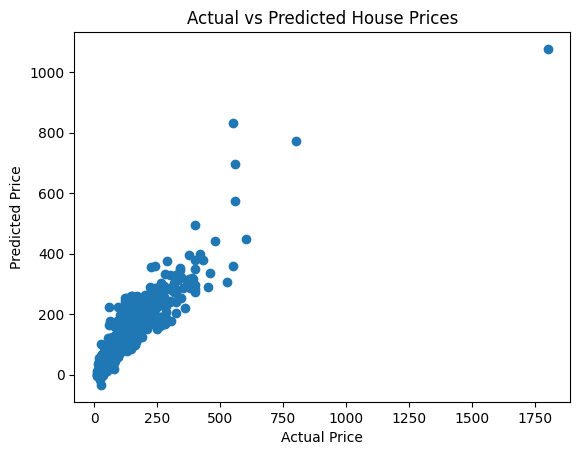

In [29]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [30]:
def predict_price(location, area_type, total_sqft, bath, balcony, bhk):
    input_data = pd.DataFrame(
        np.zeros((1, X.shape[1])),
        columns=X.columns
    )

    input_data["total_sqft"] = total_sqft
    input_data["bath"] = bath
    input_data["balcony"] = balcony
    input_data["bhk"] = bhk

    area_col = "area_type_" + area_type
    location_col = "location_" + location

    if area_col in input_data.columns:
        input_data[area_col] = 1

    if location_col in input_data.columns:
        input_data[location_col] = 1

    return lr.predict(input_data)[0]

In [31]:
predict_price(
    location="Whitefield",
    area_type="Super built-up Area",
    total_sqft=1200,
    bath=2,
    balcony=1,
    bhk=2
)


66.14940570364682

***

In [32]:
import os
import pickle
import json

os.makedirs("../Models", exist_ok=True)

with open("../Models/house_price_model.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("../Models/model_columns.json", "w") as f:
    json.dump(list(X.columns), f)

In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Decision Tree

In [34]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

print("R2:", dt.score(X_test, y_test))

R2: 0.8389073312844868


# Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("R2:", rf.score(X_test, y_test))

R2: 0.8550077539559094


#### Interpretation

Decision Tree (0.8389)

* Very close to Linear Regression.
* Captures non-linear relationships.
* Slightly worse than Linear Regression.

Random Forest (0.8550)

* Best model among all tested.
* Improves over Linear Regression by: 0.8550 - 0.8411 = 0.0139

In [36]:
from sklearn.model_selection import cross_val_score, ShuffleSplit

cv = ShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.85500775 0.83439536 0.77848732 0.81513439 0.86289126]
0.8291832175924851


Interpretation

* Random Forest achieved the highest score on the test split (0.8550).
* Linear Regression achieved the highest average cross-validation score (0.8467).
* Linear Regression showed more consistent performance across multiple train-test partitions.
* Random Forest appears slightly more sensitive to the particular split of data.

Although Random Forest Regressor achieved the highest test-set R² score (0.8550), Linear Regression demonstrated superior cross-validation performance (0.8467) and greater consistency. Therefore, Linear Regression was selected as the final model.

- Random Forest CV R² = 0.8292
- Linear Regression CV R² = 0.8467
  
Therefore, Linear Regression was selected because it performed more consistently across multiple splits.


***
***
***
# AutoML
***
***
***

In [37]:
from pycaret.regression import *

automl_df = df_final.copy()

s = setup(
    data=automl_df,
    target="price",
    session_id=42,
    train_size=0.8,
    fold=5,
    html=False,
    verbose=False
)

best_model = compare_models(sort="R2")

                                    Model       MAE           MSE       RMSE  \
lr                      Linear Regression   18.1719  1.369659e+03    36.4248   
br                         Bayesian Ridge   18.0668  1.375022e+03    36.4834   
ridge                    Ridge Regression   18.0603  1.377193e+03    36.5190   
et                  Extra Trees Regressor   15.8063  1.636808e+03    38.4902   
omp           Orthogonal Matching Pursuit   20.3617  1.522525e+03    38.4676   
rf                Random Forest Regressor   16.2372  1.635003e+03    39.3877   
gbr           Gradient Boosting Regressor   19.0866  1.911284e+03    42.5282   
huber                     Huber Regressor   21.9121  2.259973e+03    47.3416   
lightgbm  Light Gradient Boosting Machine   19.4771  2.437083e+03    47.8922   
lasso                    Lasso Regression   23.7162  2.298144e+03    47.7028   
llar         Lasso Least Angle Regression   23.7162  2.298158e+03    47.7030   
dt                Decision Tree Regresso

In [38]:
results = pull()
results

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,18.1719,1.369659e+03,36.4248,0.8392,0.3395,0.2125,0.956
br,Bayesian Ridge,18.0668,1.375022e+03,36.4834,0.8391,0.3279,0.2094,0.082
ridge,Ridge Regression,18.0603,1.377193e+03,36.5190,0.8388,0.3263,0.2087,0.484
et,Extra Trees Regressor,15.8063,1.636808e+03,38.4902,0.8229,0.2171,0.1557,1.112
omp,Orthogonal Matching Pursuit,20.3617,1.522525e+03,38.4676,0.8209,0.3434,0.2353,0.024
rf,Random Forest Regressor,16.2372,1.635003e+03,39.3877,0.8144,0.2144,0.1573,0.910
gbr,Gradient Boosting Regressor,19.0866,1.911284e+03,42.5282,0.7828,0.2530,0.2142,0.276
huber,Huber Regressor,21.9121,2.259973e+03,47.3416,0.7300,0.3302,0.2236,0.362
lightgbm,Light Gradient Boosting Machine,19.4771,2.437083e+03,47.8922,0.7282,0.2408,0.1913,0.436
lasso,Lasso Regression,23.7162,2.298144e+03,47.7028,0.7265,0.3579,0.2614,0.618


In [39]:
best_model

LinearRegression(n_jobs=-1)

In [40]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [41]:
rf = create_model('rf')
tuned_rf = tune_model(rf)

          MAE        MSE     RMSE      R2   RMSLE    MAPE
Fold                                                     
0     17.3531  2018.2449  44.9249  0.8189  0.2141  0.1551
1     15.9526  1186.8411  34.4506  0.8292  0.2275  0.1677
2     15.8143   770.0382  27.7496  0.8873  0.2213  0.1642
3     15.6709  2919.8454  54.0356  0.7211  0.2000  0.1428
4     16.3951  1280.0431  35.7777  0.8153  0.2089  0.1570
Mean  16.2372  1635.0025  39.3877  0.8144  0.2144  0.1573
Std    0.6084   757.9847   9.1441  0.0534  0.0095  0.0086


Processing:   0%|                                        | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
          MAE        MSE     RMSE      R2   RMSLE    MAPE
Fold                                                     
0     23.1898  3031.9768  55.0634  0.7280  0.2749  0.2287
1     21.6582  1703.8311  41.2775  0.7548  0.2905  0.2409
2     21.6636  1483.5572  38.5170  0.7829  0.2822  0.2390
3     21.6490  2628.3742  51.2677  0.7489  0.2741  0.2279
4     22.0076  1717.2751  41.4400  0.7522  0.2706  0.2263
Mean  22.0337  2113.0029  45.5131  0.7534  0.2785  0.2326
Std    0.5938   605.0363   6.4467  0.0175  0.0071  0.0061


In [42]:
final_model = finalize_model(best_model)

In [43]:
save_model(
    final_model,
    "../Models/pycaret_best_model"
)

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['total_sqft', 'bath', 'balcony',
                                              'bhk'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('clean_column_names',
                  TransformerWrapper(transformer=CleanColumnNames())),
                 ('actual_estimator', LinearRegression(n_jobs=-1))]),
 '../Models/pycaret_best_model.pkl')

In [44]:
results.to_csv(
    "../Models/pycaret_results.csv",
    index=False
)